# Final Homework — Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Course:** Introduction to Data Science  
**Student:** Israel Sarel Cohen  
**Dataset:** Hotel Booking Demand (20,000-row working sample)  
**Random seed:** 42

This notebook is a self-contained solution for the final homework. It focuses only on the required unsupervised-learning tasks: exploratory analysis, PCA, clustering, feature-space clustering, multidimensional anomaly detection, method comparison, critical reflection, and an optional visualization dashboard.

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Reproducibility and methodological principle</b><br>All stochastic methods use <code>random_state=42</code>. The analysis deliberately excludes outcome/status columns from the unsupervised feature matrix, so the geometry, clusters, and anomalies are not guided by a supervised target. Exact duplicate rows are retained because the public data are anonymized and multiple genuinely different bookings can become identical after identifying information is removed.
</div>

## 0. Setup and data loading

In [1]:
import os, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from scipy.stats import skew, kurtosis
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

candidate_files = [
    Path('hotel_booking_homework3.csv'),
    Path('/content/hotel_booking_homework3.csv'),
    Path('hotel_booking_homework2.csv'),
    Path('/content/hotel_booking_homework2.csv'),
]

data_path = next((p for p in candidate_files if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Place hotel_booking_homework3.csv in the same folder as this notebook (or upload it to /content in Colab).'
    )

df = pd.read_csv(data_path)
print(f'Loaded: {data_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head())

Loaded: hotel_booking_homework3.csv
Shape: 20,000 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,City Hotel,0,4,2017,June,23,6,0,2,2,0.0,0,BB,GBR,Direct,Direct,0,0,0,F,F,0,No Deposit,14.0,NaN,0,Transient,245.00,0,0,Check-Out,2017-06-08
1,City Hotel,1,204,2017,April,16,21,0,1,2,0.0,0,BB,NLD,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,9.0,NaN,0,Transient,103.05,0,2,Canceled,2017-03-24
2,Resort Hotel,0,152,2016,April,17,20,0,4,2,0.0,0,BB,IRL,Groups,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient-Party,50.50,0,1,Check-Out,2016-04-24
3,City Hotel,0,35,2017,March,13,26,2,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,123.00,0,0,Check-Out,2017-03-28
4,City Hotel,0,273,2015,July,29,17,0,2,1,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,No Deposit,6.0,NaN,0,Transient-Party,87.00,0,0,Check-Out,2015-07-19


## 1. Dataset Selection (10%)

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Dataset origin, collection purpose, and collectors</b><br>The underlying Hotel Booking Demand data were published by Nuno António, Ana de Almeida, and Luís Nunes in <i>Data in Brief</i> (2019), DOI: 10.1016/j.dib.2018.11.126. The original publication contains real booking records from a resort hotel and a city hotel in Portugal, covering arrivals from July 2015 through August 2017. The data were made available for research and education in areas such as revenue management, machine learning, and data mining. Personal identifying information was removed. The submitted CSV used here is a 20,000-row working sample of the combined hotel-booking data, so rare-event frequencies may differ slightly from the full publication dataset.
</div>

### 1.1 Feature dictionary

In [2]:
feature_dictionary = {
    'hotel': 'Hotel type: Resort Hotel or City Hotel.',
    'is_canceled': '1 if the booking was canceled, 0 otherwise.',
    'lead_time': 'Days between booking entry and arrival date.',
    'arrival_date_year': 'Arrival year.',
    'arrival_date_month': 'Arrival month.',
    'arrival_date_week_number': 'Arrival ISO-style week number.',
    'arrival_date_day_of_month': 'Arrival day of month.',
    'stays_in_weekend_nights': 'Number of weekend nights booked/stayed.',
    'stays_in_week_nights': 'Number of weekday nights booked/stayed.',
    'adults': 'Number of adults in the booking.',
    'children': 'Number of children in the booking.',
    'babies': 'Number of babies in the booking.',
    'meal': 'Booked meal package/category.',
    'country': 'Guest country of origin code.',
    'market_segment': 'Market segment classification.',
    'distribution_channel': 'Booking distribution channel.',
    'is_repeated_guest': 'Indicator that the guest had booked previously.',
    'previous_cancellations': 'Number of previous bookings canceled by the customer.',
    'previous_bookings_not_canceled': 'Number of previous bookings not canceled by the customer.',
    'reserved_room_type': 'Anonymized code for reserved room type.',
    'assigned_room_type': 'Anonymized code for assigned room type.',
    'booking_changes': 'Number of booking changes/amendments.',
    'deposit_type': 'Deposit policy/type.',
    'agent': 'Anonymized travel-agent identifier.',
    'company': 'Anonymized company/entity identifier.',
    'days_in_waiting_list': 'Days the booking spent on a waiting list.',
    'customer_type': 'Customer type (e.g., transient, group, contract).',
    'adr': 'Average Daily Rate for the booking.',
    'required_car_parking_spaces': 'Number of requested parking spaces.',
    'total_of_special_requests': 'Number of special requests made by the guest.',
    'reservation_status': 'Final/current reservation status.',
    'reservation_status_date': 'Date at which reservation status was set/updated.'
}

feature_use = {
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
    'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list',
    'adr', 'required_car_parking_spaces', 'total_of_special_requests'
}

feature_table = pd.DataFrame({
    'feature': df.columns,
    'description': [feature_dictionary.get(c, 'Not documented in local dictionary.') for c in df.columns],
    'used_in_unsupervised_matrix': [c in feature_use for c in df.columns]
})
display(feature_table)

,feature,description,used_in_unsupervised_matrix
0,hotel,Hotel type: Resort Hotel or City Hotel.,False
1,is_canceled,"1 if the booking was canceled, 0 otherwise.",False
2,lead_time,Days between booking entry and arrival date.,True
3,arrival_date_year,Arrival year.,False
4,arrival_date_month,Arrival month.,False
5,arrival_date_week_number,Arrival ISO-style week number.,False
6,arrival_date_day_of_month,Arrival day of month.,False
7,stays_in_weekend_nights,Number of weekend nights booked/stayed.,True
8,stays_in_week_nights,Number of weekday nights booked/stayed.,True
9,adults,Number of adults in the booking.,True


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Feature-selection justification</b><br>The primary unsupervised matrix uses 13 numerical behavioral/transactional features. Outcome/status fields such as <code>is_canceled</code>, <code>reservation_status</code>, and <code>reservation_status_date</code> are excluded so they do not act as hidden labels. Numeric identifiers (<code>agent</code>, <code>company</code>) are excluded because arithmetic distance between ID codes has no natural meaning. Calendar fields are excluded from the main Euclidean geometry because month/week/day are cyclic/time encodings rather than ordinary continuous magnitudes. The rare binary field <code>is_repeated_guest</code> is reserved for post-hoc interpretation because standardizing a very rare binary value can give it disproportionate Euclidean leverage.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Possible limitations and biases</b><br>The data describe only two Portuguese hotels during a limited time period, so conclusions may not generalize to other countries, hotel classes, or market conditions. The data are anonymized, so duplicate-looking rows may correspond to distinct real bookings. Some variables are highly skewed and sparse, which can distort means, standard deviations, Euclidean distances, and PCA. The working file is a 20,000-row sample rather than the full dataset, so very rare behaviors can be under- or over-represented. Finally, an unusual booking is not automatically an error or harmful event; anomaly labels are inherently contextual.
</div>

## 2. Exploratory Data Analysis (15%)

### 2.1 Structural analysis

In [3]:
print('Rows, columns:', df.shape)
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

missing = df.isna().sum().sort_values(ascending=False)
print('\nMissing values:')
display(missing[missing > 0].to_frame('missing_count'))

print('\nStatistical summary (numeric):')
display(df.describe(include=[np.number]).T)

print(f'Exact duplicate rows: {df.duplicated().sum():,}')

Rows, columns: (20000, 32)

Data types:


,dtype
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64



Missing values:


,missing_count
company,18879
agent,2792
country,87
children,1



Statistical summary (numeric):


,count,mean,std,min,25%,50%,75%,max
is_canceled,20000.0,0.370400,0.482924,0.00,0.0,0.0,1.0,1.0
lead_time,20000.0,102.802800,105.708461,0.00,18.0,68.0,159.0,629.0
arrival_date_year,20000.0,2016.157150,0.705747,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,20000.0,27.108300,13.621984,1.00,16.0,27.0,38.0,53.0
arrival_date_day_of_month,20000.0,15.886800,8.818417,1.00,8.0,16.0,24.0,31.0
stays_in_weekend_nights,20000.0,0.919850,0.991804,0.00,0.0,1.0,2.0,12.0
stays_in_week_nights,20000.0,2.511000,1.915193,0.00,1.0,2.0,3.0,30.0
adults,20000.0,1.857000,0.534851,0.00,2.0,2.0,2.0,27.0
children,19999.0,0.101655,0.394122,0.00,0.0,0.0,0.0,3.0
babies,20000.0,0.008100,0.112406,0.00,0.0,0.0,0.0,10.0


Exact duplicate rows: 3,077


In [4]:
selected_features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
X_raw = df[selected_features].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=selected_features,
    index=df.index
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print('Selected unsupervised feature matrix:', X_imputed.shape)
print('Missing values after median imputation:', int(X_imputed.isna().sum().sum()))

Selected unsupervised feature matrix: (20000, 13)
Missing values after median imputation: 0


### 2.2 Correlation matrix

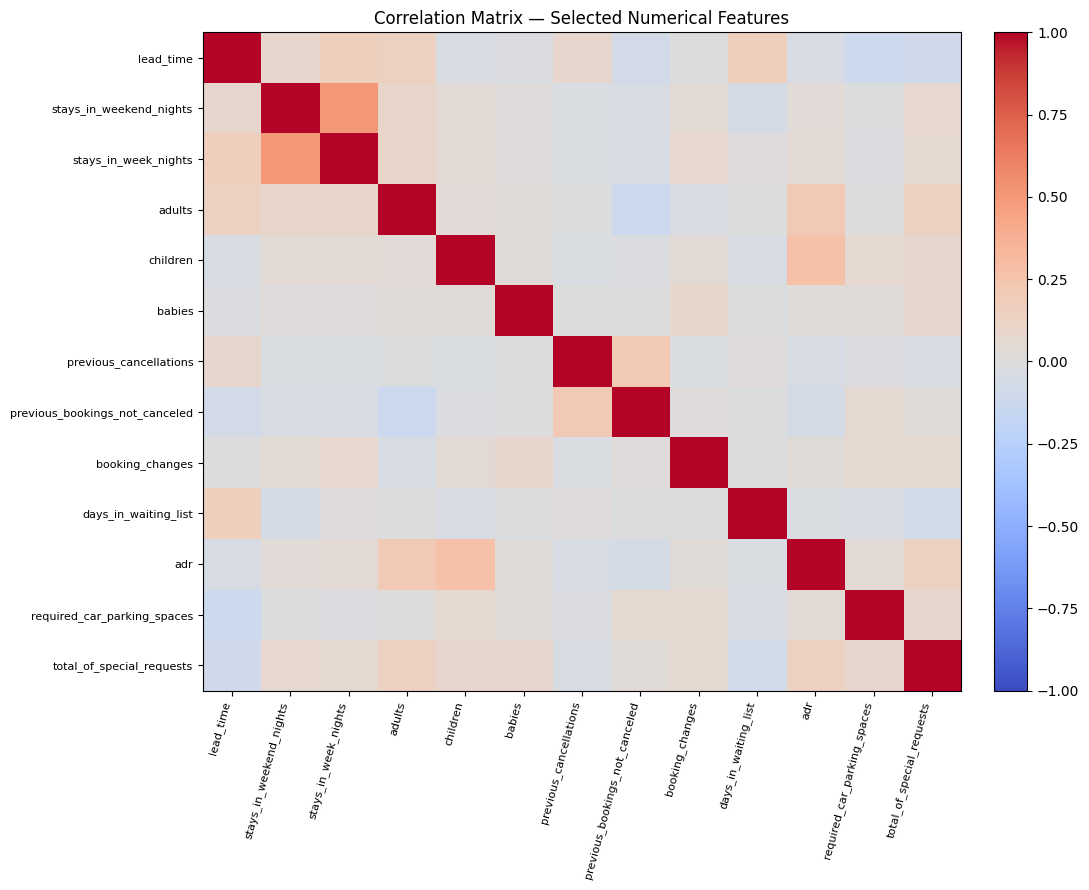

,abs_corr,corr,feature_1,feature_2
0,0.501662,0.501662,stays_in_weekend_nights,stays_in_week_nights
1,0.269450,0.269450,children,adr
2,0.209413,0.209413,previous_cancellations,previous_bookings_not_canceled
3,0.207755,0.207755,adults,adr
4,0.165482,0.165482,lead_time,stays_in_week_nights
5,0.163099,0.163099,lead_time,days_in_waiting_list
6,0.138675,0.138675,adr,total_of_special_requests
7,0.136907,0.136907,adults,total_of_special_requests
8,0.136499,0.136499,lead_time,adults
9,0.119840,-0.119840,adults,previous_bookings_not_canceled


In [5]:
corr = X_imputed.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, aspect='auto', vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(selected_features)))
ax.set_yticks(range(len(selected_features)))
ax.set_xticklabels(selected_features, rotation=75, ha='right', fontsize=8)
ax.set_yticklabels(selected_features, fontsize=8)
ax.set_title('Correlation Matrix — Selected Numerical Features')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

pairs=[]
for i,a in enumerate(selected_features):
    for j,b in enumerate(selected_features):
        if j>i:
            pairs.append((abs(corr.loc[a,b]), corr.loc[a,b], a, b))
top_corr = pd.DataFrame(sorted(pairs, reverse=True)[:10], columns=['abs_corr','corr','feature_1','feature_2'])
display(top_corr)

### 2.3 Distribution analysis: histogram, boxplot, skewness, kurtosis

,feature,skewness,excess_kurtosis,min,median,max
5,babies,40.557085,3170.354208,0.00,0.0,10.0
10,adr,33.249830,2844.165587,-6.38,95.0,5400.0
6,previous_cancellations,26.312452,822.717772,0.00,0.0,26.0
7,previous_bookings_not_canceled,22.960389,719.549526,0.00,0.0,70.0
9,days_in_waiting_list,10.669806,149.536449,0.00,0.0,391.0
3,adults,6.758040,310.472192,0.00,2.0,27.0
8,booking_changes,4.628291,35.832126,0.00,0.0,13.0
4,children,4.055712,15.947737,0.00,0.0,3.0
11,required_car_parking_spaces,3.710185,12.625257,0.00,0.0,3.0
2,stays_in_week_nights,2.576734,15.838552,0.00,2.0,30.0


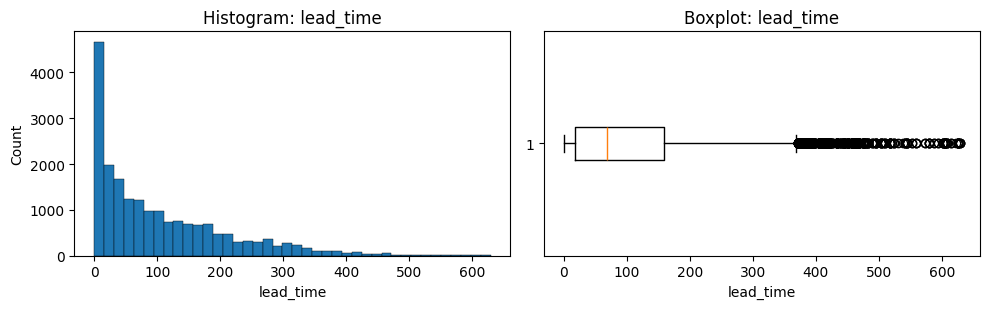

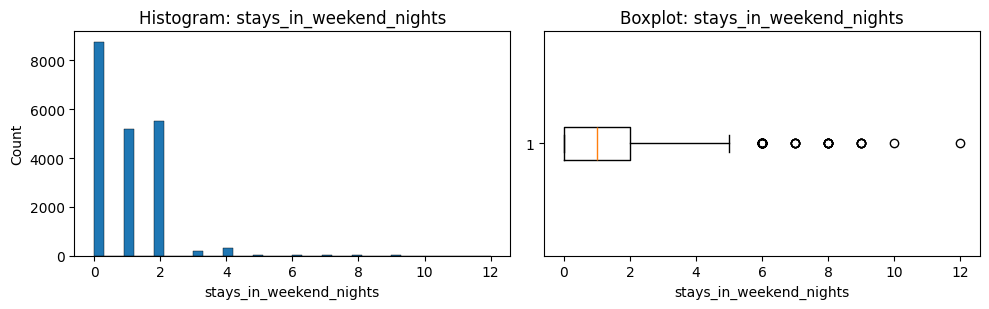

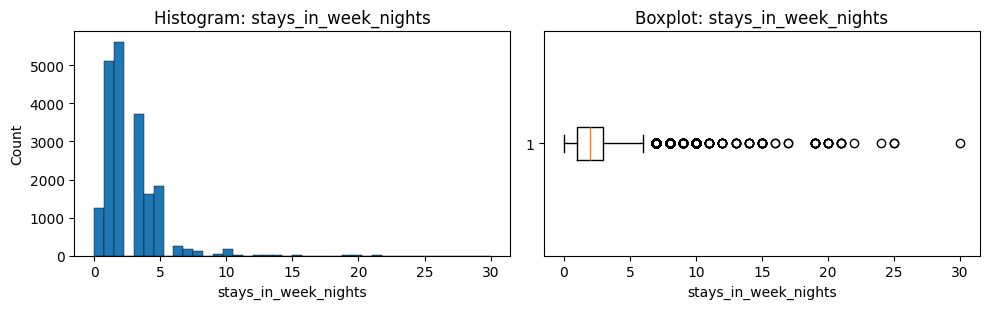

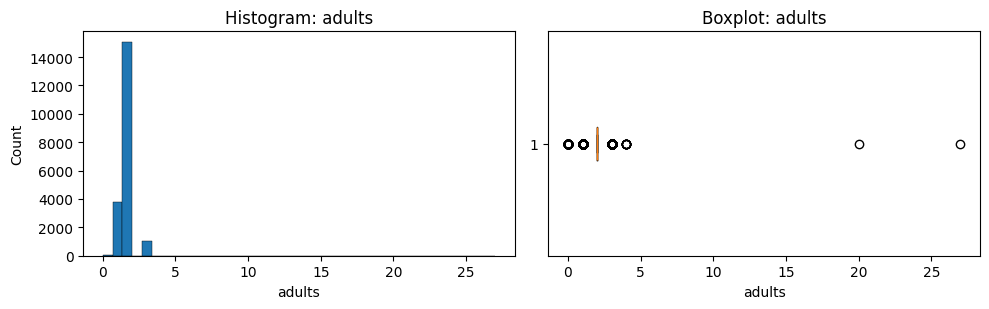

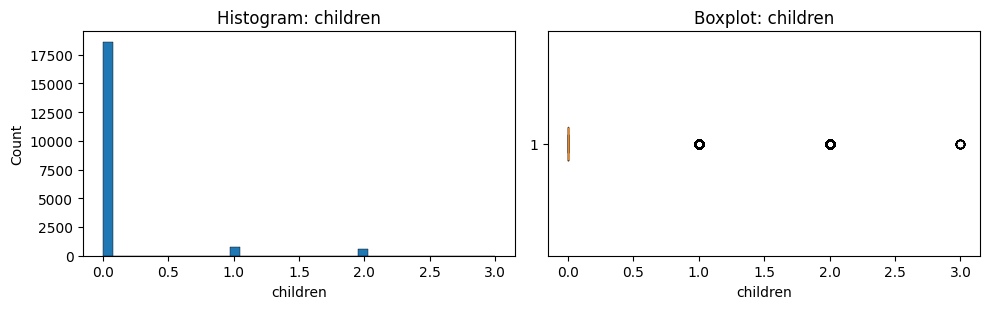

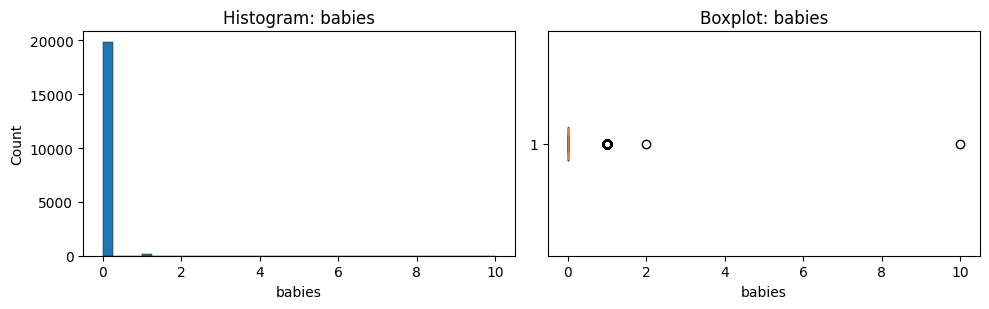

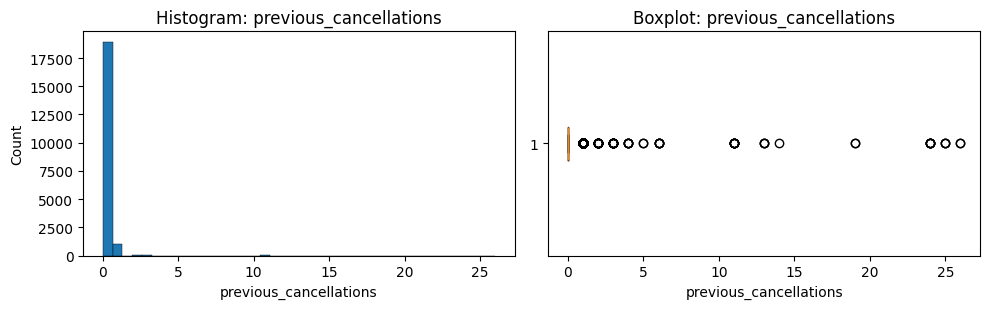

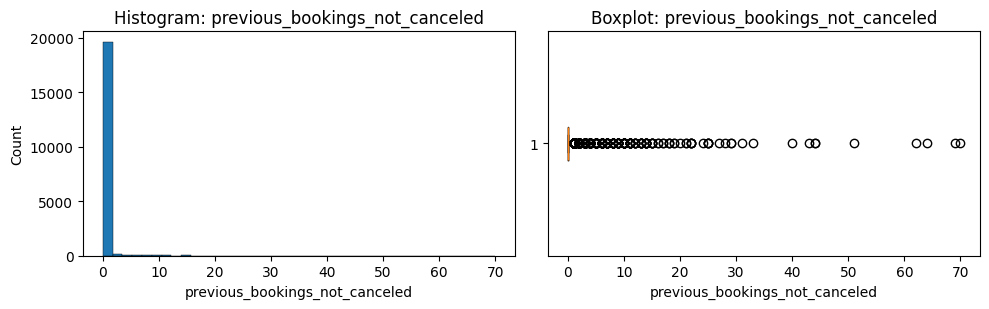

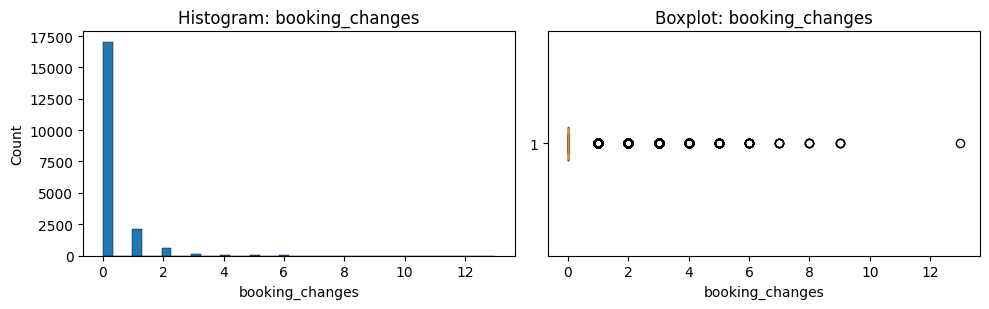

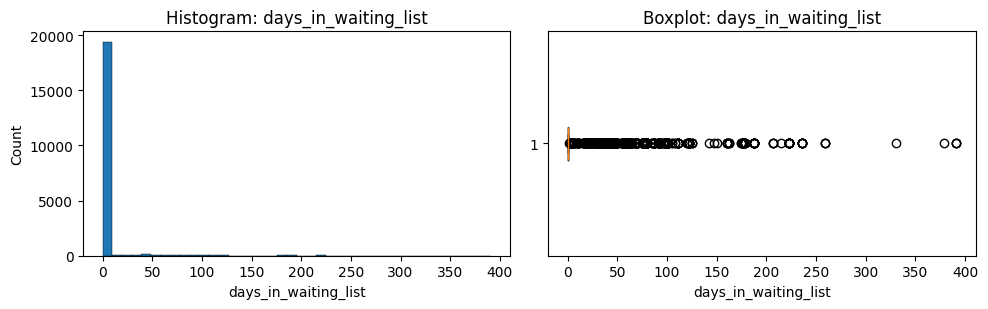

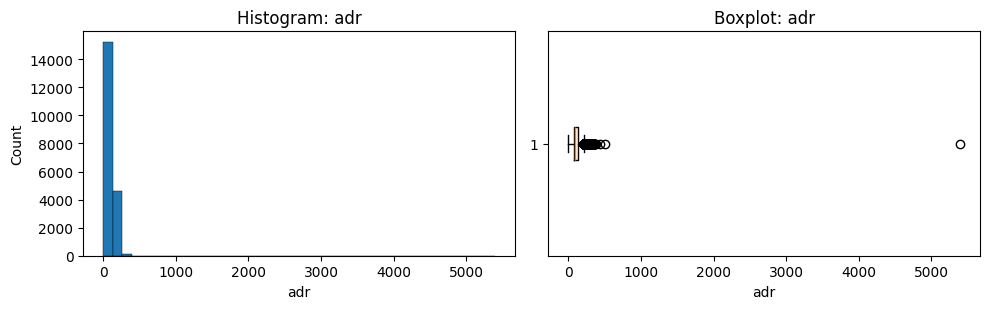

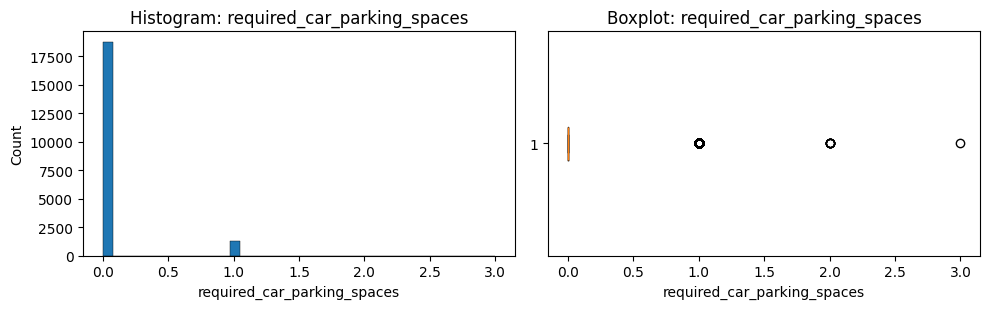

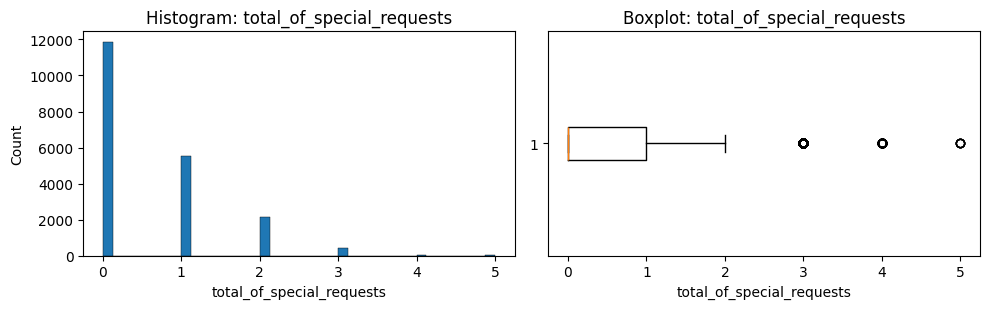

In [6]:
dist_rows=[]
for col in selected_features:
    s=X_imputed[col]
    dist_rows.append({
        'feature': col,
        'skewness': skew(s, bias=False),
        'excess_kurtosis': kurtosis(s, fisher=True, bias=False),
        'min': s.min(), 'median': s.median(), 'max': s.max()
    })

dist_stats = pd.DataFrame(dist_rows).sort_values('skewness', ascending=False)
display(dist_stats)

for col in selected_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].hist(X_imputed[col], bins=40, edgecolor='black', linewidth=0.3)
    axes[0].set_title(f'Histogram: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[1].boxplot(X_imputed[col], vert=False)
    axes[1].set_title(f'Boxplot: {col}')
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

### 2.4 Outlier exploration and data-quality checks

In [7]:
iqr_rows=[]
for col in selected_features:
    q1,q3=X_imputed[col].quantile([0.25,0.75])
    iqr=q3-q1
    lo=q1-1.5*iqr
    hi=q3+1.5*iqr
    count=((X_imputed[col]<lo)|(X_imputed[col]>hi)).sum()
    iqr_rows.append({'feature':col,'Q1':q1,'Q3':q3,'IQR':iqr,'IQR_outlier_count':int(count)})
iqr_table=pd.DataFrame(iqr_rows).sort_values('IQR_outlier_count',ascending=False)
display(iqr_table)

quality_checks = pd.Series({
    'negative_adr': int((df['adr'] < 0).sum()),
    'zero_total_guests': int(((df['adults'].fillna(0)+df['children'].fillna(0)+df['babies'].fillna(0)) == 0).sum()),
    'children_missing': int(df['children'].isna().sum()),
    'exact_duplicate_rows': int(df.duplicated().sum()),
})
display(quality_checks.to_frame('count'))

,feature,Q1,Q3,IQR,IQR_outlier_count
3,adults,2.0,2.0,0.0,4940
8,booking_changes,0.0,0.0,0.0,2977
4,children,0.0,0.0,0.0,1403
11,required_car_parking_spaces,0.0,0.0,0.0,1256
6,previous_cancellations,0.0,0.0,0.0,1078
10,adr,70.0,126.0,56.0,648
9,days_in_waiting_list,0.0,0.0,0.0,635
7,previous_bookings_not_canceled,0.0,0.0,0.0,613
2,stays_in_week_nights,1.0,3.0,2.0,587
12,total_of_special_requests,0.0,1.0,1.0,477


,count
negative_adr,1
zero_total_guests,27
children_missing,1
exact_duplicate_rows,3077


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>EDA interpretation</b><br>The distributions are strongly non-Gaussian: several count variables contain a large mass at zero plus a long right tail, while ADR contains an extreme upper tail. This matters because classical Z-scores use mean and standard deviation, PCA is sensitive to high-leverage observations, and Euclidean clustering can be dominated by sparse extreme dimensions. The moderate correlation between weekend and weekday stay lengths suggests some redundancy, but most pairwise correlations are not strong. Exact duplicate rows are not automatically removed: because guest identifiers were stripped, two genuinely separate bookings can look identical. Suspicious observations such as negative ADR or a booking with zero recorded guests are preserved for anomaly analysis rather than silently deleted.
</div>

## 3. Dimensionality Reduction — Principal Component Analysis (20%)

### 3.1 Mathematical intuition
For a standardized data matrix $X$, PCA finds orthogonal directions of maximum variance. If $\Sigma$ is the covariance matrix,

$$\Sigma v_j = \lambda_j v_j$$

where $v_j$ is the $j$th principal direction and $\lambda_j$ is its variance. The explained-variance ratio is

$$\text{EVR}_j = \frac{\lambda_j}{\sum_k \lambda_k}.$$

PCA is a **global linear** projection: it summarizes variance across the full dataset, but it does not explicitly preserve local neighborhoods or nonlinear structure.

In [8]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

n90 = int(np.argmax(cum_evr >= 0.90) + 1)
n95 = int(np.argmax(cum_evr >= 0.95) + 1)
print(f'Components for >=90% variance: {n90} / {len(selected_features)}')
print(f'Components for >=95% variance: {n95} / {len(selected_features)}')
print(f'Cumulative variance in 2 PCs: {cum_evr[1]:.3f}')
print(f'Cumulative variance in 3 PCs: {cum_evr[2]:.3f}')

Components for >=90% variance: 11 / 13
Components for >=95% variance: 12 / 13
Cumulative variance in 2 PCs: 0.247
Cumulative variance in 3 PCs: 0.344


### 3.2 Explained variance and scree plot

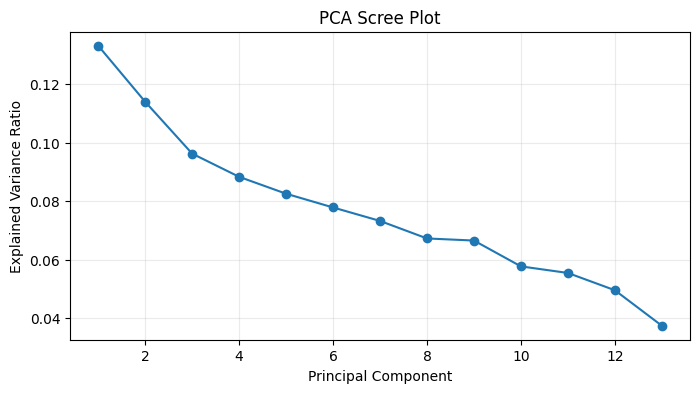

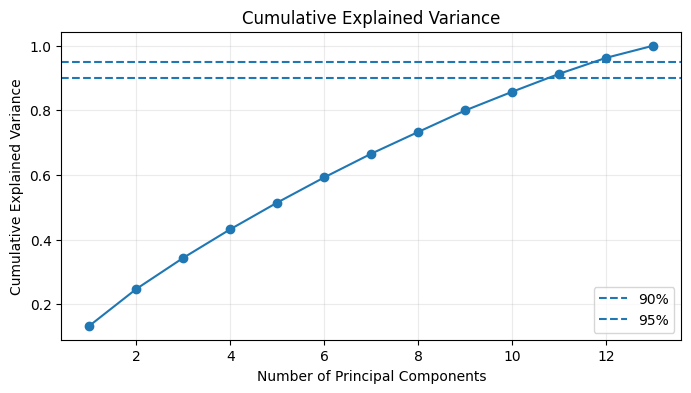

In [9]:
plt.figure(figsize=(8,4))
plt.plot(range(1,len(evr)+1), evr, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot')
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1,len(cum_evr)+1), cum_evr, marker='o')
plt.axhline(0.90, linestyle='--', label='90%')
plt.axhline(0.95, linestyle='--', label='95%')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### 3.3 2D and 3D projections

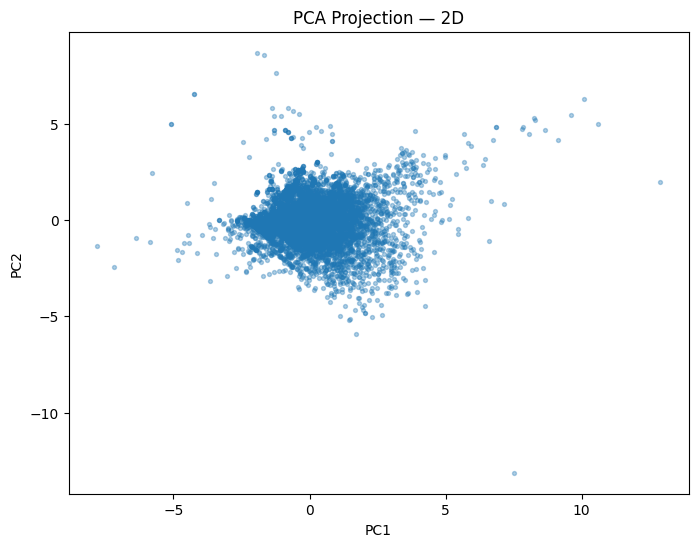

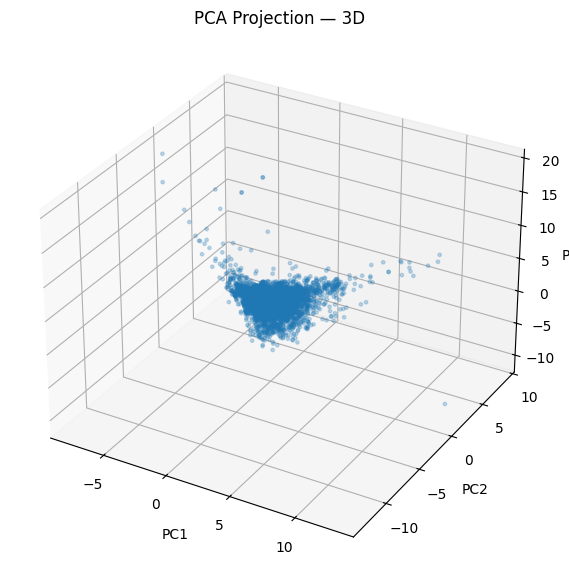

In [10]:
plot_idx = np.random.default_rng(RANDOM_STATE).choice(len(df), size=min(8000,len(df)), replace=False)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[plot_idx,0], X_pca[plot_idx,1], s=8, alpha=0.35)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection — 2D')
plt.show()

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[plot_idx,0], X_pca[plot_idx,1], X_pca[plot_idx,2], s=6, alpha=0.25)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('PCA Projection — 3D')
plt.show()

### 3.4 Component interpretation (loadings)

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f'PC{i+1}' for i in range(len(selected_features))]
)
for pc in ['PC1','PC2','PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(6).index
    print(f'\nTop contributors to {pc}:')
    display(loadings.loc[top,[pc]].sort_values(pc, key=np.abs, ascending=False))


Top contributors to PC1:


,PC1
stays_in_week_nights,0.525384
stays_in_weekend_nights,0.509210
adults,0.351405
adr,0.320436
total_of_special_requests,0.262480
children,0.241586



Top contributors to PC2:


,PC2
lead_time,0.490631
adr,-0.367742
total_of_special_requests,-0.349379
children,-0.342268
required_car_parking_spaces,-0.318700
stays_in_week_nights,0.300417



Top contributors to PC3:


,PC3
previous_bookings_not_canceled,0.519807
adults,-0.338839
stays_in_weekend_nights,0.320552
previous_cancellations,0.313530
booking_changes,0.302372
adr,-0.277261


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>PCA interpretation and information loss</b><br>The first two components explain only about one quarter of the standardized variance, and the first three explain roughly one third. Approximately 11 of the 13 components are required to reach 90% explained variance, so the dataset has limited linear redundancy. The 2D/3D plots are therefore useful visual summaries, but they are not lossless representations of the original geometry. PC1 is driven mainly by stay length and party/rate-related variables; PC2 contrasts lead time with ADR, children, parking, and special requests; PC3 contains strong booking-history contributions. Because many dimensions remain necessary, aggressive dimensionality reduction would discard meaningful information.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Local vs global structure, stability, cost, interpretability, redundancy</b><br>PCA captures global linear variance rather than local neighborhood structure. It is deterministic after preprocessing, but its axes can change when extreme observations or the selected variables change. With 20,000 rows and only 13 modeled features, PCA is computationally inexpensive. Loadings make the linear components interpretable, but the 2D/3D projections can exaggerate or hide apparent separation. The need for 11 components to preserve 90% variance indicates that the original feature set is not highly redundant, although the two stay-length variables are related.
</div>

## 4. Clustering Analysis (20%)

### 4.1 Evaluation framework
The required “average variance within clusters vs global variance” is implemented as a weighted ratio:

$$R_{var}=\frac{\sum_c n_c\,\overline{Var}(X_c)/\sum_c n_c}{\overline{Var}(X)}.$$

A smaller value indicates tighter clusters relative to the overall spread. However, this metric favors compact groups and is not fully suitable for arbitrary-density or non-spherical clusters. Therefore it is supplemented with **Silhouette**, **Calinski–Harabasz**, and **Davies–Bouldin** scores. For DBSCAN, noise points are excluded from the internal cluster metrics.

In [12]:
def variance_ratio(X, labels, ignore_noise=False):
    labels=np.asarray(labels)
    mask=np.ones(len(labels),dtype=bool)
    if ignore_noise:
        mask=labels!=-1
    X2=X[mask]; y=labels[mask]
    global_var=np.mean(np.var(X2,axis=0,ddof=0))
    numerator=0.0; n=0
    for c in np.unique(y):
        xc=X2[y==c]
        if len(xc)>1:
            numerator += len(xc)*np.mean(np.var(xc,axis=0,ddof=0))
            n += len(xc)
    return (numerator/n)/global_var

def cluster_metrics(X, labels, ignore_noise=False, sample_size=5000):
    labels=np.asarray(labels)
    mask=np.ones(len(labels),dtype=bool)
    if ignore_noise:
        mask=labels!=-1
    X2=X[mask]; y=labels[mask]
    k=len(np.unique(y))
    if k < 2:
        return {'n_clusters':k,'silhouette':np.nan,'calinski_harabasz':np.nan,'davies_bouldin':np.nan,'variance_ratio':np.nan}
    sil=silhouette_score(X2,y,sample_size=min(sample_size,len(X2)),random_state=RANDOM_STATE)
    return {
        'n_clusters':k,
        'silhouette':sil,
        'calinski_harabasz':calinski_harabasz_score(X2,y),
        'davies_bouldin':davies_bouldin_score(X2,y),
        'variance_ratio':variance_ratio(X,labels,ignore_noise=ignore_noise)
    }

### 4.2 K-Means

K-Means alternates between assigning each point to its nearest centroid and updating each centroid to the mean of its assigned points. It approximately minimizes

$$\sum_{i=1}^{n}\|x_i-\mu_{c_i}\|_2^2.$$

**Assumptions:** Euclidean distance is meaningful; clusters are roughly compact/spherical; features are on comparable scales.  
**Strengths:** fast, scalable, easy to interpret.  
**Weaknesses:** requires $k$, is sensitive to initialization/outliers, and performs poorly on non-convex or strongly unequal-density clusters.

,k,inertia,silhouette,runtime_sec,min_cluster_size
0,2,239350.683193,0.184818,1.663495,6412
1,3,221883.557718,0.164863,2.061961,1265
2,4,205093.303646,0.183282,1.675801,1187
3,5,194482.112592,0.142375,1.572818,328
4,6,178219.667902,0.204015,2.420472,41


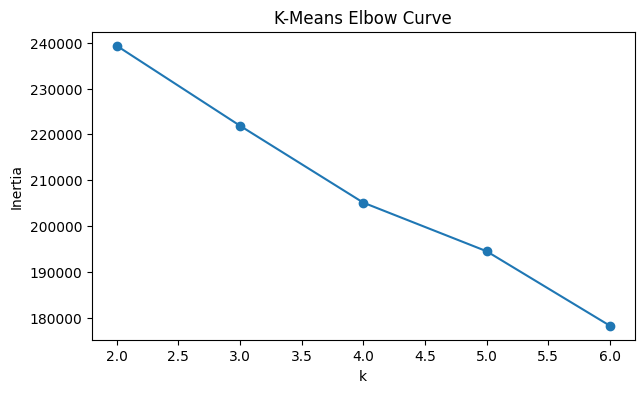

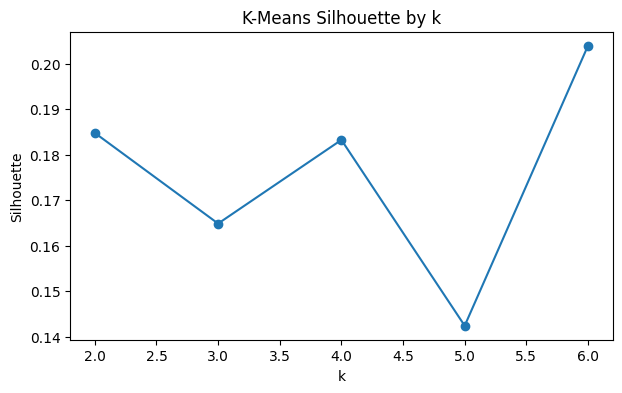

0    13588
1     6412
Name: count, dtype: int64


,n_clusters,silhouette,calinski_harabasz,davies_bouldin,variance_ratio
K-Means k=2,2,0.184818,1725.287094,2.650311,0.920579


In [13]:
kmeans_scan=[]
for k in range(2,7):
    t0=time.perf_counter()
    model=KMeans(n_clusters=k,n_init=10,random_state=RANDOM_STATE)
    labels=model.fit_predict(X_scaled)
    kmeans_scan.append({
        'k':k,
        'inertia':model.inertia_,
        'silhouette':silhouette_score(X_scaled,labels,sample_size=5000,random_state=RANDOM_STATE),
        'runtime_sec':time.perf_counter()-t0,
        'min_cluster_size':pd.Series(labels).value_counts().min()
    })
kmeans_scan=pd.DataFrame(kmeans_scan)
display(kmeans_scan)

plt.figure(figsize=(7,4))
plt.plot(kmeans_scan['k'],kmeans_scan['inertia'],marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('K-Means Elbow Curve')
plt.show()

plt.figure(figsize=(7,4))
plt.plot(kmeans_scan['k'],kmeans_scan['silhouette'],marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('K-Means Silhouette by k')
plt.show()

# Parsimonious final choice: k=2. Higher-k solutions create tiny groups that behave more like outlier buckets.
kmeans = KMeans(n_clusters=2,n_init=10,random_state=RANDOM_STATE)
kmeans_labels=kmeans.fit_predict(X_scaled)
print(pd.Series(kmeans_labels).value_counts().sort_index())
display(pd.DataFrame([cluster_metrics(X_scaled,kmeans_labels)],index=['K-Means k=2']))

In [14]:
profile = X_imputed.copy()
profile['cluster']=kmeans_labels
print('K-Means cluster means:')
display(profile.groupby('cluster').mean().T)

context = df[['hotel','customer_type','is_repeated_guest']].copy()
context['cluster']=kmeans_labels
print('Hotel composition by cluster:')
display(pd.crosstab(context['cluster'],context['hotel'],normalize='index').round(3))
print('Customer-type composition by cluster:')
display(pd.crosstab(context['cluster'],context['customer_type'],normalize='index').round(3))
print('Repeated-guest rate by cluster (post-hoc descriptor; not used in clustering):')
display(context.groupby('cluster')['is_repeated_guest'].mean().to_frame('repeated_guest_rate'))

K-Means cluster means:


cluster,0,1
lead_time,100.342582,108.016376
stays_in_weekend_nights,0.582941,1.633812
stays_in_week_nights,1.868266,3.873051
adults,1.752208,2.079070
children,0.012290,0.291017
babies,0.000736,0.023706
previous_cancellations,0.110465,0.015284
previous_bookings_not_canceled,0.213865,0.026513
booking_changes,0.137842,0.380536
days_in_waiting_list,3.339049,0.071117


Hotel composition by cluster:


hotel,City Hotel,Resort Hotel
cluster,,
0,0.734,0.266
1,0.515,0.485


Customer-type composition by cluster:


customer_type,Contract,Group,Transient,Transient-Party
cluster,,,,
0,0.022,0.004,0.717,0.257
1,0.055,0.003,0.834,0.107


Repeated-guest rate by cluster (post-hoc descriptor; not used in clustering):


,repeated_guest_rate
cluster,
0,0.042096
1,0.009825


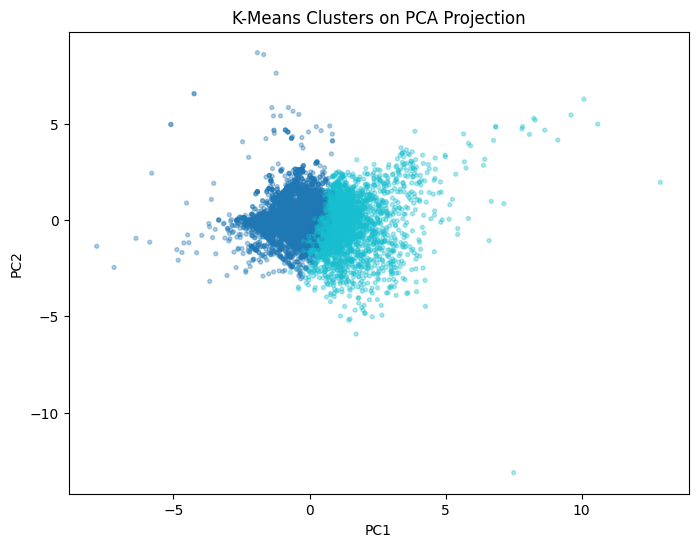

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[plot_idx,0],X_pca[plot_idx,1],c=kmeans_labels[plot_idx],s=8,alpha=0.35,cmap='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('K-Means Clusters on PCA Projection')
plt.show()

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>K-Means interpretation</b><br>The two-cluster solution is used as a parsimonious representation rather than chasing a slightly better score at larger k that is partly produced by very small extreme-value groups. One cluster has longer stays, larger parties, higher ADR, more parking, and more special requests; the other has shorter stays and lower average spend. These are behavioral segments, not ground-truth customer classes. The modest silhouette score warns that the boundary is not naturally sharp.
</div>

### 4.3 DBSCAN

DBSCAN forms clusters from dense regions. A **core point** has at least <code>min_samples</code> observations within radius $\varepsilon$. Clusters are connected sets of density-reachable points; points that are not density-reachable from a core point are labeled noise.

**Strengths:** no need to choose the number of clusters; finds non-spherical shapes; explicitly identifies noise.  
**Weaknesses:** very sensitive to $\varepsilon$, <code>min_samples</code>, scaling, and changing density; Euclidean neighborhoods become less meaningful in higher dimensions.

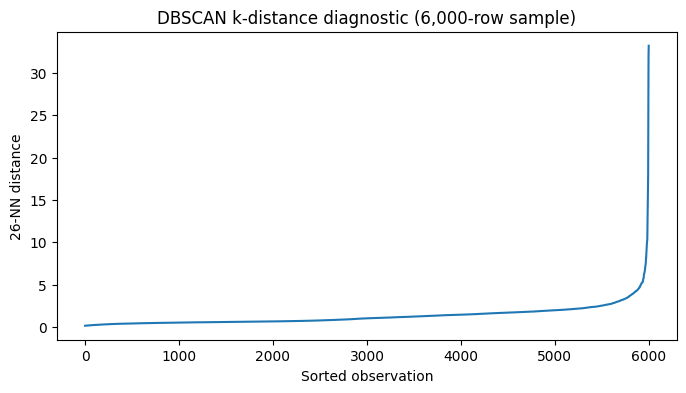

,eps,n_clusters,noise_rate,silhouette_non_noise,runtime_sec
0,2.00,4,0.072333,0.211562,1.789498
1,2.35,4,0.049167,0.228539,1.370590
2,2.67,2,0.037667,0.359280,1.815287
3,3.13,2,0.026500,0.365998,2.485986


-1     226
 0    5475
 1     299
Name: count, dtype: int64


,n_clusters,silhouette,calinski_harabasz,davies_bouldin,variance_ratio
DBSCAN eps=2.67,2,0.359766,678.471156,1.138611,0.894818


In [16]:
# DBSCAN can become expensive on all 20,000 points because neighborhood search grows quickly.
# Use a fixed 6,000-row subsample for a reproducible density-based analysis.
rng_db=np.random.default_rng(RANDOM_STATE)
db_idx=rng_db.choice(len(X_scaled),size=6000,replace=False)
X_db=X_scaled[db_idx]

min_samples = 2*X_db.shape[1]
knn = NearestNeighbors(n_neighbors=min_samples,n_jobs=1).fit(X_db)
dists,_ = knn.kneighbors(X_db)
kdist = np.sort(dists[:,-1])

plt.figure(figsize=(8,4))
plt.plot(kdist)
plt.ylabel(f'{min_samples}-NN distance')
plt.xlabel('Sorted observation')
plt.title('DBSCAN k-distance diagnostic (6,000-row sample)')
plt.show()

candidate_eps=[2.0,2.35,2.67,3.13]
dbscan_scan=[]
for eps in candidate_eps:
    t0=time.perf_counter()
    labels=DBSCAN(eps=eps,min_samples=min_samples,n_jobs=1).fit_predict(X_db)
    n_clusters=len(set(labels))-(1 if -1 in labels else 0)
    noise_rate=(labels==-1).mean()
    sil=np.nan
    mask=labels!=-1
    if n_clusters>=2 and mask.sum()>100:
        sil=silhouette_score(X_db[mask],labels[mask],sample_size=min(3000,mask.sum()),random_state=RANDOM_STATE)
    dbscan_scan.append({'eps':eps,'n_clusters':n_clusters,'noise_rate':noise_rate,'silhouette_non_noise':sil,'runtime_sec':time.perf_counter()-t0})
dbscan_scan=pd.DataFrame(dbscan_scan)
display(dbscan_scan)

# Chosen as a compromise between excessive fragmentation and excessive merging.
dbscan = DBSCAN(eps=2.67,min_samples=min_samples,n_jobs=1)
dbscan_labels=dbscan.fit_predict(X_db)
print(pd.Series(dbscan_labels).value_counts().sort_index())
display(pd.DataFrame([cluster_metrics(X_db,dbscan_labels,ignore_noise=True)],index=['DBSCAN eps=2.67']))

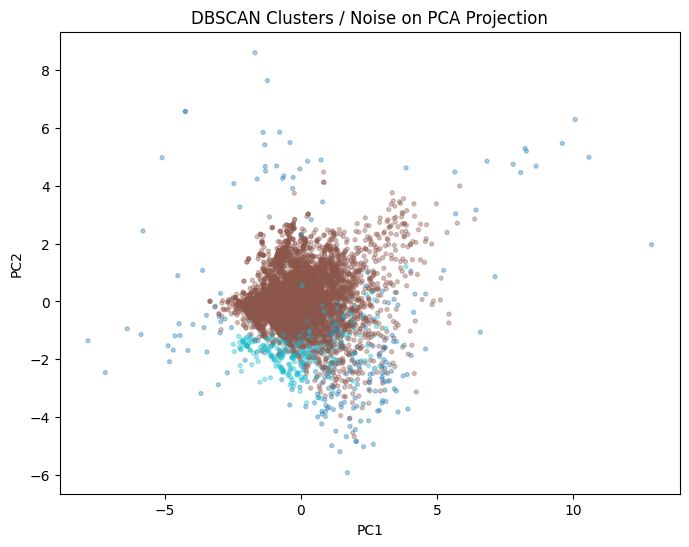

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[db_idx,0],X_pca[db_idx,1],c=dbscan_labels,s=8,alpha=0.35,cmap='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('DBSCAN Clusters / Noise on PCA Projection')
plt.show()

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>DBSCAN interpretation</b><br>On its reproducible 6,000-row analysis sample, DBSCAN produces a dominant dense region, a smaller dense region, and a noise set. This differs from K-Means because DBSCAN asks whether points have enough nearby neighbors rather than forcing every booking into a centroid-based partition. The parameter scan shows the expected sensitivity: smaller ε fragments the data and increases the noise rate, while larger ε merges structures and absorbs more observations into the dominant cluster. In this high-dimensional, skewed dataset, DBSCAN noise should be interpreted as low local density, not automatically as a business error.
</div>

### 4.4 Hierarchical Clustering

Agglomerative hierarchical clustering starts with one cluster per observation and repeatedly merges clusters. With **Ward linkage**, the selected merge is the one that causes the smallest increase in within-cluster sum of squares.

**Strengths:** provides a hierarchy and does not require committing to a single partition at the beginning.  
**Weaknesses:** standard agglomerative methods have roughly quadratic memory/time behavior and can be sensitive to distance/linkage choices. For that reason, the sample-space hierarchical analysis uses a fixed 3,000-row reproducible subsample while DBSCAN uses a fixed 6,000-row sample for neighborhood scalability and K-Means uses all 20,000 rows.

In [18]:
rng=np.random.default_rng(RANDOM_STATE)
hier_idx=rng.choice(len(X_scaled),size=3000,replace=False)
X_hier=X_scaled[hier_idx]

hier_scan=[]
for k in range(2,7):
    t0=time.perf_counter()
    labels=AgglomerativeClustering(n_clusters=k,linkage='ward').fit_predict(X_hier)
    hier_scan.append({
        'k':k,
        'silhouette':silhouette_score(X_hier,labels),
        'calinski_harabasz':calinski_harabasz_score(X_hier,labels),
        'davies_bouldin':davies_bouldin_score(X_hier,labels),
        'min_cluster_size':pd.Series(labels).value_counts().min(),
        'runtime_sec':time.perf_counter()-t0
    })
hier_scan=pd.DataFrame(hier_scan)
display(hier_scan)

hier = AgglomerativeClustering(n_clusters=2,linkage='ward')
hier_labels=hier.fit_predict(X_hier)
print(pd.Series(hier_labels).value_counts().sort_index())
display(pd.DataFrame([cluster_metrics(X_hier,hier_labels)],index=['Hierarchical k=2']))

,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,runtime_sec
0,2,0.341229,273.887579,2.176356,354,0.361674
1,3,0.344987,264.796226,1.499362,2,0.335201
2,4,0.343002,272.985305,1.124149,2,0.316822
3,5,0.166836,280.605573,1.356458,2,0.337778
4,6,0.186624,294.582185,1.283122,2,0.313488


0    2646
1     354
Name: count, dtype: int64


,n_clusters,silhouette,calinski_harabasz,davies_bouldin,variance_ratio
Hierarchical k=2,2,0.341229,273.887579,2.176356,0.916291


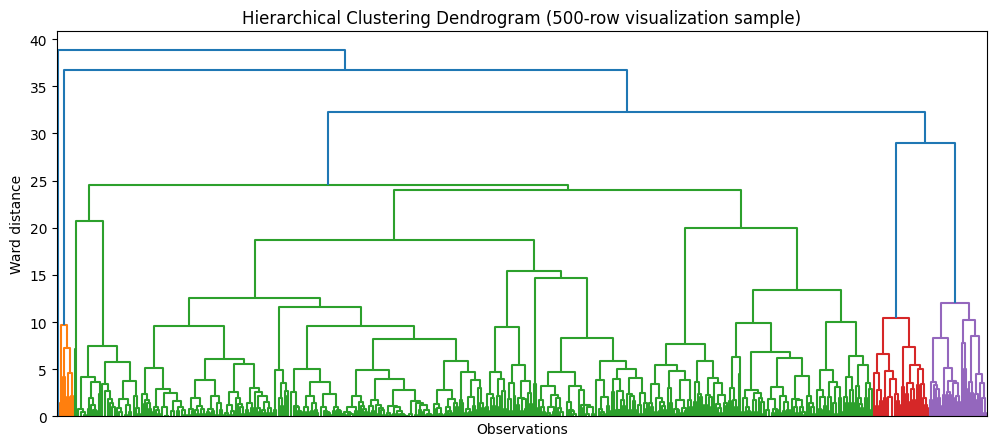

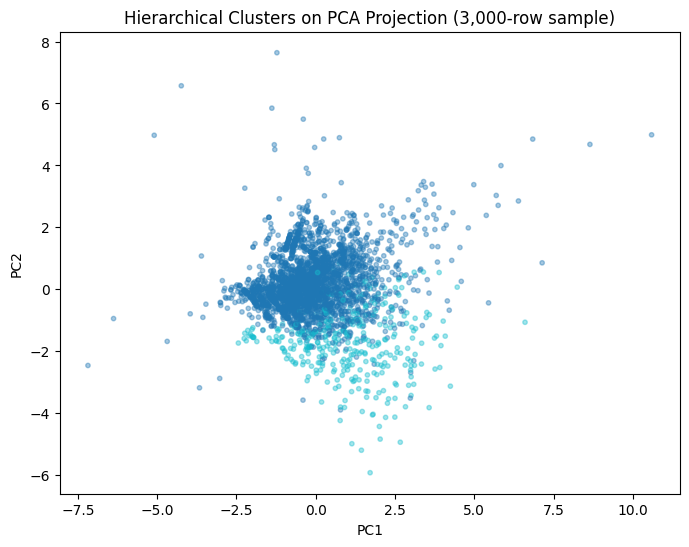

In [19]:
# Dendrogram on a smaller subset only for readable visualization.
dend_idx=rng.choice(len(X_scaled),size=500,replace=False)
Z=linkage(X_scaled[dend_idx],method='ward')
plt.figure(figsize=(12,5))
dendrogram(Z,no_labels=True,color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (500-row visualization sample)')
plt.xlabel('Observations'); plt.ylabel('Ward distance')
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_pca[hier_idx,0],X_pca[hier_idx,1],c=hier_labels,s=10,alpha=0.4,cmap='tab10')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Hierarchical Clusters on PCA Projection (3,000-row sample)')
plt.show()

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Hierarchical interpretation</b><br>A two-group cut is preferred for the main hierarchical summary because higher-k solutions begin to isolate very small branches. The method reveals a large central population and a smaller behaviorally distinct group. Its result is not expected to exactly match K-Means because Ward uses a greedy merge history and the hierarchical analysis is performed on a reproducible sample for computational reasons.
</div>

### 4.5 Comparison of sample-space clustering methods

In [20]:
cluster_compare = pd.DataFrame([
    {'method':'K-Means','rows_used':len(X_scaled),**cluster_metrics(X_scaled,kmeans_labels)},
    {'method':'DBSCAN','rows_used':len(X_db),'noise_rate':(dbscan_labels==-1).mean(),**cluster_metrics(X_db,dbscan_labels,ignore_noise=True)},
    {'method':'Hierarchical (Ward)','rows_used':len(X_hier),**cluster_metrics(X_hier,hier_labels)},
])
display(cluster_compare)

,method,rows_used,n_clusters,silhouette,calinski_harabasz,davies_bouldin,variance_ratio,noise_rate
0,K-Means,20000,2,0.184818,1725.287094,2.650311,0.920579,NaN
1,DBSCAN,6000,2,0.359766,678.471156,1.138611,0.894818,0.037667
2,Hierarchical (Ward),3000,2,0.341229,273.887579,2.176356,0.916291,NaN


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Why the clustering algorithms disagree</b><br>K-Means is centroid-based and forces every observation into a compact Voronoi region; DBSCAN is density-based and can leave points unassigned as noise; Ward hierarchical clustering greedily merges observations to control within-cluster variance. Different assumptions about geometry therefore produce different partitions. The variance ratio is informative for compactness but is not sufficient for DBSCAN, so silhouette and other metrics are reported too. Clustering can fail when distance is dominated by skewed sparse features, when densities vary strongly, when groups overlap, or when the real data simply do not contain discrete segments.
</div>

### 4.6 Clustering the feature space (transpose of the data matrix)

,k,silhouette
0,2,0.044743
1,3,0.050957
2,4,0.049455
3,5,0.045804
4,6,0.078601


,feature,feature_cluster
5,babies,0
8,booking_changes,0
10,adr,1
3,adults,1
4,children,1
12,total_of_special_requests,1
7,previous_bookings_not_canceled,2
6,previous_cancellations,2
9,days_in_waiting_list,3
0,lead_time,3


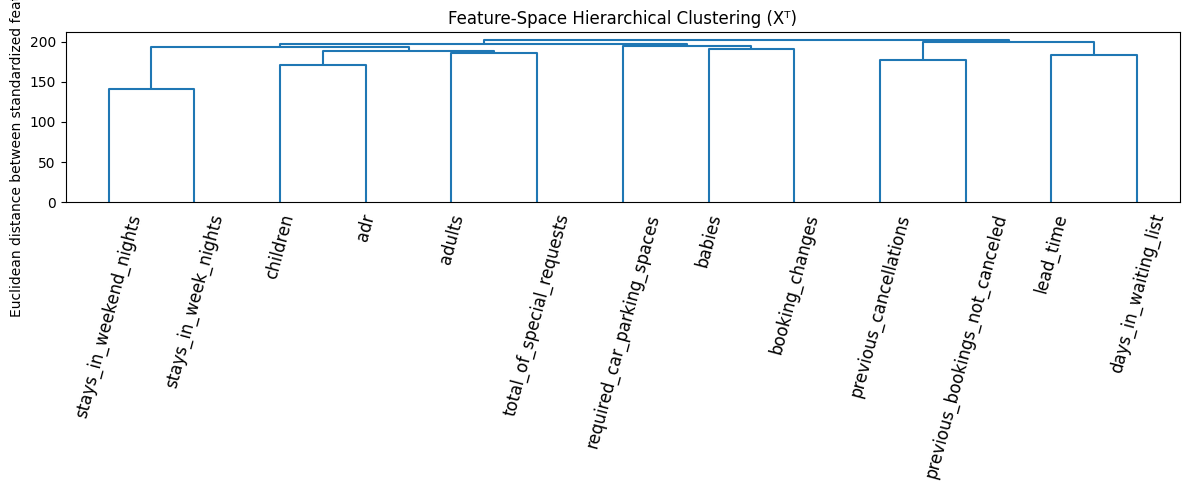

In [21]:
# X_scaled is (samples x features). Transposing treats each feature as an object described by all samples.
feature_space = X_scaled.T
feature_scan=[]
for k in range(2,7):
    lab=AgglomerativeClustering(n_clusters=k,linkage='average',metric='euclidean').fit_predict(feature_space)
    feature_scan.append({'k':k,'silhouette':silhouette_score(feature_space,lab)})
feature_scan=pd.DataFrame(feature_scan)
display(feature_scan)

best_feature_k=int(feature_scan.sort_values('silhouette',ascending=False).iloc[0]['k'])
feature_model=AgglomerativeClustering(n_clusters=best_feature_k,linkage='average',metric='euclidean')
feature_labels=feature_model.fit_predict(feature_space)
feature_groups=pd.DataFrame({'feature':selected_features,'feature_cluster':feature_labels}).sort_values(['feature_cluster','feature'])
display(feature_groups)

Zf=linkage(feature_space,method='average',metric='euclidean')
plt.figure(figsize=(12,5))
dendrogram(Zf,labels=selected_features,leaf_rotation=75)
plt.title('Feature-Space Hierarchical Clustering (Xᵀ)')
plt.ylabel('Euclidean distance between standardized feature vectors')
plt.tight_layout()
plt.show()

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Feature-space interpretation</b><br>Feature clustering reveals relationships that sample clustering does not show directly. Stay-in-week and stay-in-weekend nights tend to group together; previous-cancellation and previous-successful-booking counts also form a related history pair; lead time and waiting-list time are closer to each other than to most transaction variables. Some sparse variables remain relatively isolated. Importantly, the feature-clustering silhouettes are low, so these are weak dependency groupings rather than sharply separated feature families. This analysis is useful in domains with many sensors, financial ratios, gene measurements, or engineered variables, where groups of correlated features may reveal redundancy or latent subsystems.
</div>

## 5. Multi-Dimensional Anomaly Detection (25%)

### 5.1 Z-Score Method

For feature $j$, the classical standardized score is

$$z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}.$$

A booking is flagged by the primary rule if **any** modeled feature has $|z|>3$. This is intentionally classical, but it assumes mean/standard-deviation summaries are meaningful and is vulnerable to multiple comparisons in many dimensions.

In [22]:
t0_z=time.perf_counter()
Zscores=(X_imputed-X_imputed.mean())/X_imputed.std(ddof=0)
z_flag=(Zscores.abs()>3).any(axis=1).to_numpy()
z_runtime=time.perf_counter()-t0_z
z_extreme_feature_counts=(Zscores.abs()>3).sum().sort_values(ascending=False)
print(f'Z-score anomalies: {z_flag.sum():,} ({z_flag.mean():.2%})')
display(z_extreme_feature_counts.to_frame('count_|z|>3'))

Z-score anomalies: 3,607 (18.04%)


,count_|z|>3
required_car_parking_spaces,1256
children,620
total_of_special_requests,477
stays_in_weekend_nights,370
days_in_waiting_list,334
stays_in_week_nights,285
booking_changes,259
lead_time,249
babies,152
previous_bookings_not_canceled,147


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Z-score limitations</b><br>The classical rule flags a large fraction of this dataset because many variables are zero-inflated, discrete, and heavy-tailed rather than Gaussian. In high dimensions, “any feature beyond 3σ” also accumulates false alarms across multiple tests. It detects feature-wise marginal extremes, not truly multivariate combinations. Therefore the Z-score result is treated as a baseline rather than ground truth.
</div>

### 5.2 Isolation Forest

Isolation Forest repeatedly selects a feature and a random split value. Anomalies tend to be isolated in fewer splits, so they have shorter average path length. A common anomaly score has the form

$$s(x,n)=2^{-E[h(x)]/c(n)},$$

where $E[h(x)]$ is the expected path length and $c(n)$ normalizes for sample size. Higher anomaly score means easier isolation and therefore more anomalous behavior.

In [23]:
contamination=0.03
t0_iso=time.perf_counter()
iso=IsolationForest(n_estimators=180,contamination=contamination,random_state=RANDOM_STATE,n_jobs=1)
iso.fit(X_scaled)
iso_score=-iso.score_samples(X_scaled)  # higher = more anomalous
iso_flag=(iso.predict(X_scaled)==-1)
iso_runtime=time.perf_counter()-t0_iso
print(f'Isolation Forest anomalies: {iso_flag.sum():,} ({iso_flag.mean():.2%})')

top_iso=np.argsort(iso_score)[-12:][::-1]
show_cols=['hotel','customer_type']+selected_features
iso_top_table=df.loc[top_iso,show_cols].copy()
iso_top_table['isolation_score']=iso_score[top_iso]
display(iso_top_table)

Isolation Forest anomalies: 600 (3.00%)


,hotel,customer_type,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,isolation_score
2730,Resort Hotel,Transient,5,3,5,1,0.0,0,0,6,3,0,0.00,1,3,0.701519
2510,Resort Hotel,Transient,142,4,6,2,0.0,0,1,13,0,0,184.00,1,4,0.692520
12215,Resort Hotel,Transient,125,2,2,1,0.0,0,4,12,2,0,61.50,0,4,0.672102
10427,Resort Hotel,Transient,250,4,10,2,0.0,0,0,2,0,0,201.43,1,4,0.670238
4254,City Hotel,Transient,1,0,1,1,0.0,0,5,19,1,0,0.00,0,3,0.667959
1166,Resort Hotel,Transient,52,4,9,2,2.0,0,0,0,1,0,234.54,1,0,0.664665
11722,Resort Hotel,Transient,29,4,8,2,0.0,0,0,2,5,0,140.00,1,2,0.661755
12324,Resort Hotel,Transient,29,0,3,2,0.0,0,1,11,1,8,126.50,1,4,0.660402
9641,Resort Hotel,Transient-Party,26,1,2,1,0.0,0,1,6,1,0,7.00,1,3,0.660311
14990,City Hotel,Transient,41,0,1,1,0.0,0,1,11,3,0,88.00,1,1,0.659447


In [24]:
iso_sensitivity=[]
for c in [0.01,0.03,0.05]:
    m=IsolationForest(n_estimators=120,contamination=c,random_state=RANDOM_STATE,n_jobs=1)
    f=m.fit_predict(X_scaled)==-1
    iso_sensitivity.append({'contamination':c,'flagged':int(f.sum()),'flagged_rate':f.mean()})
display(pd.DataFrame(iso_sensitivity))

,contamination,flagged,flagged_rate
0,0.01,200,0.01000
1,0.03,599,0.02995
2,0.05,1000,0.05000


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Isolation Forest interpretation</b><br>The contamination parameter does not define what an anomaly objectively is; it determines how much of the score distribution is labeled anomalous. A 3% working value is used for a focused comparison, and 1%/3%/5% sensitivity is shown. Isolation Forest is attractive in moderately high dimensions because it does not rely on pairwise distance in the same way as LOF, but it can still be unstable for borderline points and its random partitions do not directly explain the business reason for each alert.
</div>

### 5.3 Local Outlier Factor (LOF)

LOF compares the local density around a point with the local densities around its neighbors. In simplified form,

$$LOF_k(x) \approx \frac{\text{average neighbor local reachability density}}{\text{local reachability density of }x}.$$

Values around 1 indicate density similar to neighbors; larger values indicate that the point lies in a lower-density pocket than its local neighborhood. LOF is therefore designed for **local** rather than purely global anomalies.

In [25]:
lof_k=35
t0_lof=time.perf_counter()
lof=LocalOutlierFactor(n_neighbors=lof_k,contamination=0.03,n_jobs=1)
lof_pred=lof.fit_predict(X_scaled)
lof_flag=(lof_pred==-1)
lof_score=-lof.negative_outlier_factor_  # higher = more anomalous
lof_runtime=time.perf_counter()-t0_lof
print(f'LOF anomalies: {lof_flag.sum():,} ({lof_flag.mean():.2%})')

# Hyperparameter sensitivity on a fixed 5,000-row sample to keep repeated neighborhood searches tractable.
lof_sens_idx=np.random.default_rng(RANDOM_STATE).choice(len(X_scaled),size=5000,replace=False)
X_lof_sens=X_scaled[lof_sens_idx]
lof_ref=LocalOutlierFactor(n_neighbors=35,contamination=0.03,n_jobs=1).fit_predict(X_lof_sens)==-1
lof_sensitivity=[]
for k in [10,35,75]:
    m=LocalOutlierFactor(n_neighbors=k,contamination=0.03,n_jobs=1)
    f=m.fit_predict(X_lof_sens)==-1
    intersection=np.logical_and(f,lof_ref).sum()
    union=np.logical_or(f,lof_ref).sum()
    lof_sensitivity.append({'k':k,'flagged':int(f.sum()),'jaccard_vs_k35':intersection/union})
display(pd.DataFrame(lof_sensitivity))

LOF anomalies: 587 (2.94%)


,k,flagged,jaccard_vs_k35
0,10,150,0.239669
1,35,150,1.000000
2,75,149,0.317181


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>LOF interpretation</b><br>The neighborhood size k controls the scale at which “local” is defined. Small k can react to noise and micro-structure; larger k smooths local variation and moves LOF toward a more global view. Because LOF uses distance and nearest neighbors, feature scaling is essential and high-dimensional distance concentration is a major limitation.
</div>

### 5.4 Visualize anomalies in PCA space

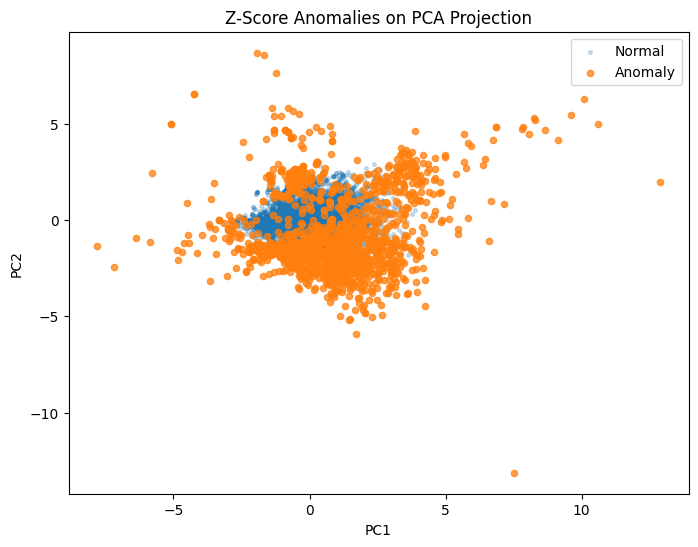

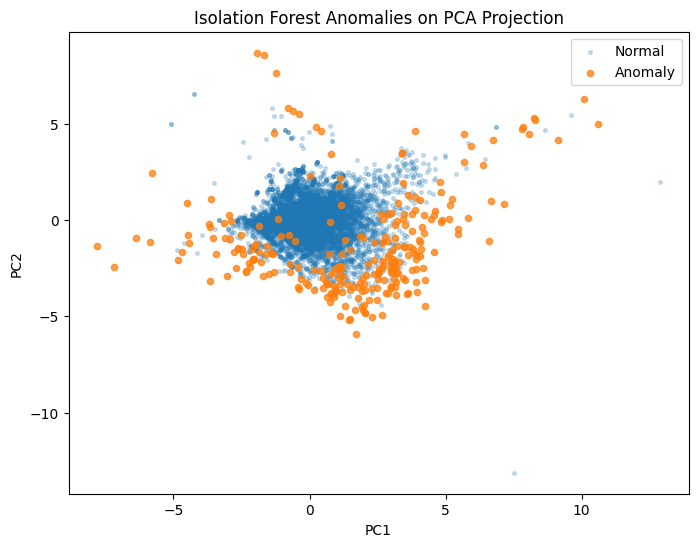

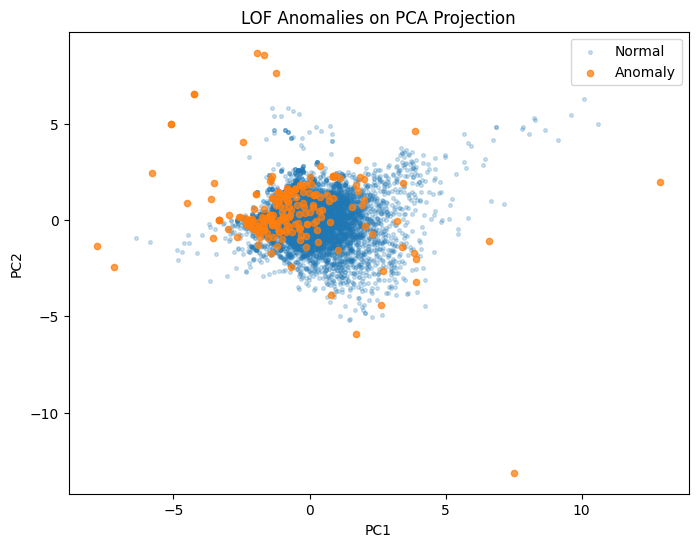

In [26]:
def plot_anomaly_flags(flag,title):
    plt.figure(figsize=(8,6))
    normal=plot_idx[~flag[plot_idx]]
    anomal=plot_idx[flag[plot_idx]]
    plt.scatter(X_pca[normal,0],X_pca[normal,1],s=7,alpha=0.22,label='Normal')
    plt.scatter(X_pca[anomal,0],X_pca[anomal,1],s=20,alpha=0.75,label='Anomaly')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(title); plt.legend(); plt.show()

plot_anomaly_flags(z_flag,'Z-Score Anomalies on PCA Projection')
plot_anomaly_flags(iso_flag,'Isolation Forest Anomalies on PCA Projection')
plot_anomaly_flags(lof_flag,'LOF Anomalies on PCA Projection')

## 6. Comparison of Anomaly Detection Methods

In [27]:
def jaccard_flags(a,b):
    a=np.asarray(a,dtype=bool); b=np.asarray(b,dtype=bool)
    inter=np.logical_and(a,b).sum(); union=np.logical_or(a,b).sum()
    return inter/union if union else np.nan

flags_df=pd.DataFrame({'Z_score':z_flag,'Isolation_Forest':iso_flag,'LOF':lof_flag},index=df.index)
flags_df['methods_flagging']=flags_df.sum(axis=1)
flags_df['consensus_2plus']=flags_df['methods_flagging']>=2

agreement=pd.DataFrame([
    {'pair':'Z-score vs Isolation Forest','jaccard':jaccard_flags(z_flag,iso_flag)},
    {'pair':'Z-score vs LOF','jaccard':jaccard_flags(z_flag,lof_flag)},
    {'pair':'Isolation Forest vs LOF','jaccard':jaccard_flags(iso_flag,lof_flag)},
])
display(agreement)
print(f'Flagged by >=2 methods: {flags_df.consensus_2plus.sum():,}')
print(f'Flagged by all 3 methods: {(flags_df.methods_flagging==3).sum():,}')
print('Method-specific only:')
display(pd.Series({
    'Z-score only':int(((flags_df.methods_flagging==1)&flags_df.Z_score).sum()),
    'Isolation Forest only':int(((flags_df.methods_flagging==1)&flags_df.Isolation_Forest).sum()),
    'LOF only':int(((flags_df.methods_flagging==1)&flags_df.LOF).sum()),
}).to_frame('count'))

,pair,jaccard
0,Z-score vs Isolation Forest,0.163440
1,Z-score vs LOF,0.034789
2,Isolation Forest vs LOF,0.045815


Flagged by >=2 methods: 684
Flagged by all 3 methods: 50
Method-specific only:


,count
Z-score only,2925
Isolation Forest only,7
LOF only,444


### 6.1 Scaling sensitivity

In [28]:
def z_method(A,threshold=3):
    A=np.asarray(A,float)
    z=(A-A.mean(axis=0))/A.std(axis=0,ddof=0)
    return (np.abs(z)>threshold).any(axis=1)

def if_method(A,contamination=0.03):
    m=IsolationForest(n_estimators=180,contamination=contamination,random_state=RANDOM_STATE,n_jobs=1)
    return m.fit_predict(A)==-1

def lof_method(A,contamination=0.03,k=35):
    m=LocalOutlierFactor(n_neighbors=k,contamination=contamination,n_jobs=1)
    return m.fit_predict(A)==-1

method_funcs={'Z-score':z_method,'Isolation Forest':if_method,'LOF':lof_method}
# Scaling sensitivity is evaluated on the same fixed 5,000 rows for both representations.
scale_idx=np.random.default_rng(RANDOM_STATE).choice(len(X_scaled),size=5000,replace=False)
raw_array=X_imputed.to_numpy()[scale_idx]
scaled_array=X_scaled[scale_idx]
scaling_rows=[]
for name,func in method_funcs.items():
    f_raw=func(raw_array)
    f_scaled=func(scaled_array)
    scaling_rows.append({'method':name,'jaccard_raw_vs_scaled':jaccard_flags(f_raw,f_scaled)})
scaling_table=pd.DataFrame(scaling_rows)
display(scaling_table)

,method,jaccard_raw_vs_scaled
0,Z-score,1.000000
1,Isolation Forest,1.000000
2,LOF,0.136364


### 6.2 Dimensionality sensitivity

In [29]:
pca90=PCA(n_components=0.90,svd_solver='full')
X_pca90=pca90.fit_transform(X_scaled)
print('PCA dimensions preserving >=90% variance:',X_pca90.shape[1])

# Use the same fixed 5,000 rows for both representations; this keeps the LOF
# neighborhood comparison computationally tractable after PCA rotation.
dim_idx=np.random.default_rng(RANDOM_STATE).choice(len(X_scaled),size=5000,replace=False)
X_dim_full=X_scaled[dim_idx]
X_dim_pca=X_pca90[dim_idx]
dim_rows=[]
for name,func in method_funcs.items():
    f_full=func(X_dim_full)
    f_reduced=func(X_dim_pca)
    dim_rows.append({'method':name,'jaccard_full_vs_PCA90':jaccard_flags(f_full,f_reduced)})
display(pd.DataFrame(dim_rows))

PCA dimensions preserving >=90% variance: 11


,method,jaccard_full_vs_PCA90
0,Z-score,0.543764
1,Isolation Forest,0.324444
2,LOF,0.587302


### 6.3 Runtime / scalability

In [30]:
runtime_table=pd.DataFrame([
    {'method':'Z-score','runtime_seconds':z_runtime},
    {'method':'Isolation Forest','runtime_seconds':iso_runtime},
    {'method':'LOF','runtime_seconds':lof_runtime},
]).sort_values('runtime_seconds')
display(runtime_table)

,method,runtime_seconds
0,Z-score,0.007384
1,Isolation Forest,0.893745
2,LOF,6.660448


### 6.4 Robustness to small measurement noise

In [31]:
rng=np.random.default_rng(RANDOM_STATE)
noise_idx=rng.choice(len(X_scaled),size=5000,replace=False)
X_noise_base=X_scaled[noise_idx]
X_noisy=X_noise_base+rng.normal(0,0.05,size=X_noise_base.shape)
noise_rows=[]
for name,func in method_funcs.items():
    f0=func(X_noise_base); fn=func(X_noisy)
    noise_rows.append({'method':name,'jaccard_original_vs_noisy':jaccard_flags(f0,fn)})
display(pd.DataFrame(noise_rows))

,method,jaccard_original_vs_noisy
0,Z-score,0.899687
1,Isolation Forest,0.764706
2,LOF,0.851852


### 6.5 Z-score threshold sensitivity

In [32]:
z_sens=[]
for threshold in [2.5,3.0,3.5,4.0]:
    f=z_method(X_scaled,threshold=threshold)
    z_sens.append({'threshold':threshold,'flagged':int(f.sum()),'flagged_rate':f.mean()})
display(pd.DataFrame(z_sens))

,threshold,flagged,flagged_rate
0,2.5,4515,0.22575
1,3.0,3607,0.18035
2,3.5,2926,0.14630
3,4.0,1570,0.07850


<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Comparison: agreement and method-specific anomalies</b><br>Agreement is limited because the methods operationalize “unusual” differently. Z-score flags marginal extremes and therefore produces many method-specific alerts in this heavy-tailed dataset. Isolation Forest searches for observations that are easy to isolate across multiple features. LOF compares local neighborhood density and can flag a point that is globally ordinary but locally sparse. The low pairwise Jaccard overlaps are evidence that anomaly detection is not a single well-defined truth in this dataset.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Comparison: scaling, dimensionality, runtime, noise, interpretability</b><br>Z-score is effectively invariant to simple linear rescaling because it standardizes each feature internally. Isolation Forest is also nearly invariant to positive linear rescaling of individual features because split order is preserved, whereas LOF changes substantially without scaling because Euclidean distance is dominated by large-unit variables. On a fixed 5,000-row sensitivity sample, reducing to the PCA space changes all methods because the projection mixes dimensions and discards some information. Z-score is computationally cheapest; Isolation Forest scales well through random trees; LOF is more expensive because it relies on neighborhood searches. The small-noise experiment shows that borderline LOF/Isolation-Forest decisions can change even when the overall pattern remains similar. Z-score is easiest to explain feature-by-feature; Isolation Forest provides a useful ranking but less direct explanations; LOF is conceptually local but can be difficult to communicate without neighborhood context.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>False positives and false negatives in this hotel context</b><br><b>False positive:</b> a legitimate booking is flagged as abnormal—for example, a long resort stay with a high ADR, several prior successful bookings, parking, and multiple special requests may simply belong to a loyal or premium customer. Excessive false alarms would waste staff attention and could lead to unfair treatment of unusual but valid customers. <b>False negative:</b> a genuinely erroneous or operationally important booking is not flagged—for example, a suspicious combination of guest counts, price, and booking history that lies inside a dense region after scaling. Because there is no anomaly ground truth here, actual false-positive and false-negative rates cannot be calculated; they must be discussed contextually.
</div>

## 7. Critical Analysis and Reflection (10%)

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Why anomaly detection is fundamentally difficult</b><br>There is no natural ground-truth boundary between normal and abnormal bookings. A rare observation may be a data-entry problem, a legitimate special case, or a valuable customer. The decision depends on the operational question, costs of errors, time period, and feature representation. Different algorithms therefore disagree for valid mathematical reasons rather than because one must be wrong.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Curse of dimensionality and distance concentration</b><br>As dimensionality grows, data become sparse and nearest/farthest distances can become less distinguishable. This weakens the meaning of Euclidean neighborhoods used by LOF and DBSCAN. More dimensions also increase the chance that a normal observation is extreme on at least one marginal feature, inflating classical Z-score flags. PCA can reduce dimension, but the comparison above shows that the anomaly set changes when information is projected away.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Noise versus genuine anomaly — dataset example</b><br>An observation with many prior successful bookings, a long stay, relatively high ADR, parking, and several special requests can receive a high Isolation-Forest score. Yet the same pattern is perfectly plausible for a loyal resort guest with an unusual but valid reservation. This illustrates why rarity alone is not equivalent to bad data. Conversely, the one negative ADR value and zero-guest records are plausible candidates for measurement/administrative artifacts, but even those require domain validation before deletion.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Risk of assuming Gaussianity</b><br>Most modeled features are counts, zero-inflated variables, or heavy-tailed transaction measures. A Gaussian model can treat common sparse events as extreme merely because the standard deviation is small, while a very broad heavy-tailed variable can hide meaningful extremes. The high Z-score flag rate in this notebook is a direct warning against treating |z|>3 as universal truth.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Why PCA visualizations can mislead</b><br>The 2D PCA view preserves only a minority of total variance. Two points that overlap in PC1–PC2 can still be far apart in discarded directions, and a cluster that looks separated in the plot may owe that appearance to projection. Therefore PCA plots are used for visualization only; clustering and anomaly detection are performed in the standardized multidimensional space, with a separate PCA sensitivity experiment.
</div>

### 7.1 Ethical considerations

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>False alarms and operational effectiveness</b><br>If hotel staff receive too many anomaly alerts, alert fatigue can cause genuinely important cases to be ignored. Thresholds should therefore be tied to the operational cost of review, not selected only because a statistical convention is familiar.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Surveillance</b><br>Anomaly systems can help identify fraud, abuse, or operational failures, but broad behavioral surveillance can invade privacy and can incorrectly treat uncommon behavior as suspicious. Data minimization, access control, auditability, and a clear legitimate purpose are necessary safeguards.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Medical applications</b><br>In healthcare, a false positive can create anxiety, unnecessary tests, and cost, while a false negative can delay diagnosis or treatment. This makes human review, calibrated risk, and domain-specific validation essential; an unsupervised anomaly score is not a diagnosis.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Cybersecurity</b><br>Missing a genuine attack can cause severe damage, while flagging legitimate activity can interrupt business and overwhelm analysts. Because attack patterns and normal behavior evolve, anomaly systems should be continuously evaluated and combined with contextual evidence rather than used as autonomous final judges.
</div>

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Privacy, bias, fairness, and labeling people as abnormal</b><br>A mathematical outlier label can inherit biases from who appears in the data and how features are measured. Rare customer groups may be over-flagged. In sensitive uses, anomaly scores should target events or transactions rather than stigmatizing individuals, and decisions should include transparency, proportionality, appeal/review mechanisms, and monitoring for disparate impact.
</div>

## 8. Optional Bonus — Visualization Dashboard (+5%)

In [33]:
# Compact interactive anomaly exploration on a reproducible sample.
try:
    import plotly.express as px
    import plotly.io as pio
    pio.renderers.default='notebook'
    dash_idx=np.random.default_rng(RANDOM_STATE).choice(len(df),size=min(5000,len(df)),replace=False)
    dash=pd.DataFrame({
        'PC1':X_pca[dash_idx,0],
        'PC2':X_pca[dash_idx,1],
        'hotel':df.loc[dash_idx,'hotel'].astype(str).values,
        'Z_score':np.where(z_flag[dash_idx],'Anomaly','Normal'),
        'Isolation_Forest':np.where(iso_flag[dash_idx],'Anomaly','Normal'),
        'LOF':np.where(lof_flag[dash_idx],'Anomaly','Normal'),
        'lead_time':df.loc[dash_idx,'lead_time'].values,
        'adr':df.loc[dash_idx,'adr'].values,
    })
    fig=px.scatter(dash,x='PC1',y='PC2',color='Isolation_Forest',hover_data=['hotel','lead_time','adr','Z_score','LOF'],title='Interactive PCA Anomaly Explorer')
    display(fig)
except Exception as e:
    print('Plotly dashboard unavailable in this environment:',e)

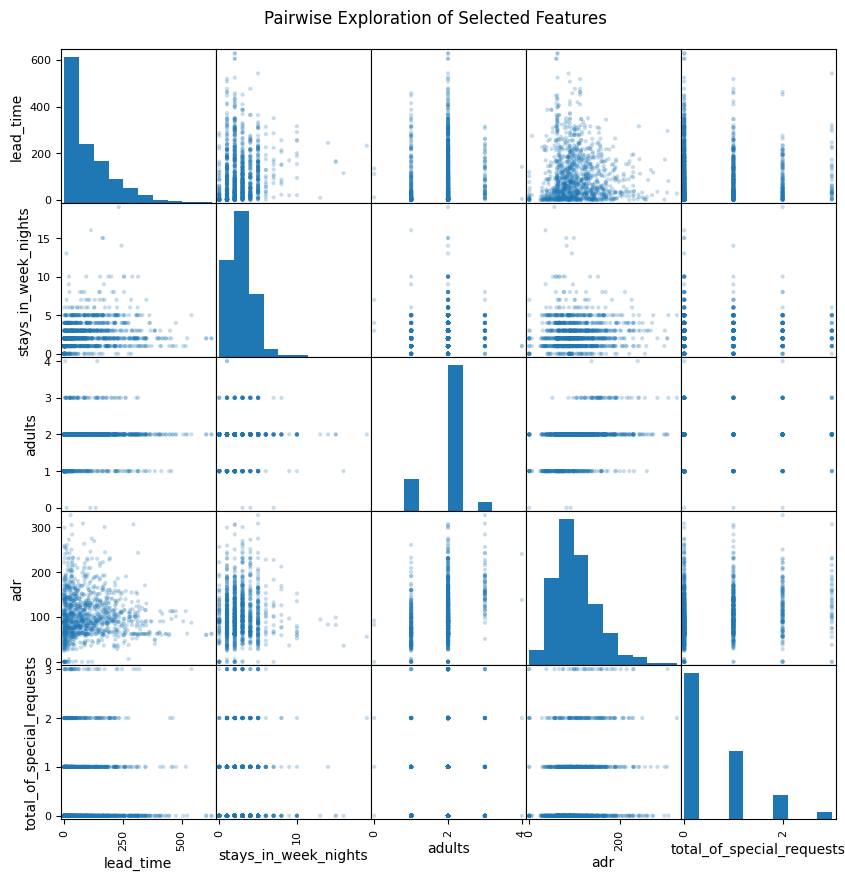

In [34]:
# Pairwise view of a compact, interpretable subset of features.
from pandas.plotting import scatter_matrix
pair_cols=['lead_time','stays_in_week_nights','adults','adr','total_of_special_requests']
pair_sample=X_imputed[pair_cols].sample(n=min(1200,len(X_imputed)),random_state=RANDOM_STATE)
axes=scatter_matrix(pair_sample,figsize=(10,10),diagonal='hist',alpha=0.25)
plt.suptitle('Pairwise Exploration of Selected Features',y=0.92)
plt.show()

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Dashboard purpose</b><br>The interactive PCA explorer supports case-level anomaly inspection with hover information, while the pairwise view and correlation heatmap support structural interpretation. These visualizations are diagnostic aids only; they do not replace the full-dimensional calculations.
</div>

## 9. Final Conclusions

<div style="border:1px solid #9aa0a6; border-radius:10px; padding:14px 16px; margin:10px 0; background:#f8f9fa;">
<b>Main conclusions</b><br>1) The Hotel Booking Demand sample satisfies the assignment requirements and contains rich numeric booking behavior, but its features are strongly skewed and heterogeneous. 2) PCA is useful for visualization, yet 11 of 13 components are needed for 90% variance, indicating limited linear redundancy and substantial information loss in 2D/3D. 3) K-Means, DBSCAN, and hierarchical clustering produce different structures because their geometric assumptions differ; none establishes a unique ground-truth segmentation. 4) Feature-space clustering reveals several related feature pairs/groups but only weak overall separation. 5) Z-score, Isolation Forest, and LOF disagree substantially, which is expected in an ill-defined anomaly problem. Z-score over-flags in this non-Gaussian setting, Isolation Forest is a practical scalable multivariate ranking method, and LOF is useful for local anomalies but is highly sensitive to scaling/neighborhood definition. 6) The most defensible operational strategy is to treat anomaly scores as evidence for review, combine multiple methods with domain knowledge, and avoid equating statistical rarity with error or wrongdoing.
</div>

## References

- António, N., de Almeida, A., & Nunes, L. (2019). *Hotel booking demand datasets*. Data in Brief, 22, 41–49. DOI: 10.1016/j.dib.2018.11.126.
- Scikit-learn documentation for PCA, KMeans, DBSCAN, AgglomerativeClustering, IsolationForest, and LocalOutlierFactor (method implementations used in this notebook).